In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import AdaBoostRegressor,RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso

In [3]:
df=pd.read_csv(r"D:\ML-project-01\dataset\data.csv")

In [4]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [6]:
x=df.drop(columns=["math_score"],axis=1)

In [7]:
y=df["math_score"]

In [10]:
numerical_feature=x.select_dtypes(exclude="object").columns
categorical_feature=x.select_dtypes(include="object").columns

from sklearn.preprocessing import  StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer 

numerical_transformation=StandardScaler()
oh_transformation=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("standerscaler",numerical_transformation,numerical_feature),
        ("onehotencoder",oh_transformation,categorical_feature)
    ]
)



In [11]:
x=preprocessor.fit_transform(x)

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [18]:
def evaluate_model(true,prediction):
    mae = mean_absolute_error(true, prediction)
    mse = mean_squared_error(true, prediction)
    r2_val = r2_score(true, prediction)
    rmse = np.sqrt(mse)

    return mae, mse, r2_val, rmse

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list=[]
r2_list=[]

for i in range(len(models)):
    model=list(models.values())[i]
    model.fit(x_train,y_train)

    y_train_prediction=model.predict(x_train)
    y_test_prediction=model.predict(x_test)

    model_train_mae,model_train_mse,model_train_r2_score,model_train_rmse=evaluate_model(y_train,y_train_prediction)
    model_test_mae,model_test_mse,model_test_r2_score,model_test_rmse=evaluate_model(y_test,y_test_prediction)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2_score))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2_score))
    r2_list.append(model_test_r2_score)
    
    print('='*35)
    print('\n')




Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.2972
- Mean Absolute Error: 4.2383
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.4825
- Mean Absolute Error: 4.3379
- R2 Score: 0.8778


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5515
- Mean Absolute Error: 5.1837
- R2 Score: 0.8077
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.6541
- Mean Absolute Error: 5.2217
- R2 Score: 0.8200


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.2976
- Mean Absolute Error: 4.2368
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.4788
- Mean Absolute Error: 4.3354
- R2 Score: 0.8780


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7890
- Mean Absolute Error: 4.5779
- R2 Score: 0.8498
-----------------------

In [20]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=["Model Name"," R2 Score"]).sort_values(by=" R2 Score",ascending=False)

,Model Name,R2 Score
2,Ridge,0.877990
0,Linear Regression,0.877824
5,Random Forest Regressor,0.854839
6,AdaBoost Regressor,0.845192
1,Lasso,0.820028
3,K-Neighbors Regressor,0.794216
4,Decision Tree,0.747000


In [24]:
linear_regression=LinearRegression()
linear_regression=linear_regression.fit(x_train,y_train)
y_prediction=linear_regression.predict(x_test)
score=r2_score(y_test,y_prediction)
print(f"Accuracy of your model is {score} ")

Accuracy of your model is 0.8778243107659015 


Text(0.5, 0, 'predicted')

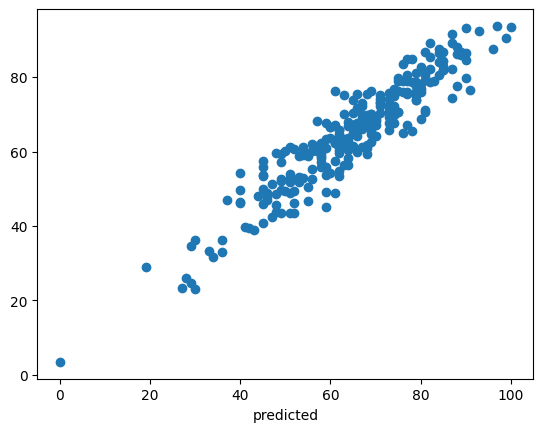

In [25]:
plt.scatter(y_test,y_prediction)
plt.xlabel("actual")
plt.xlabel("predicted")

<Axes: xlabel='math_score'>

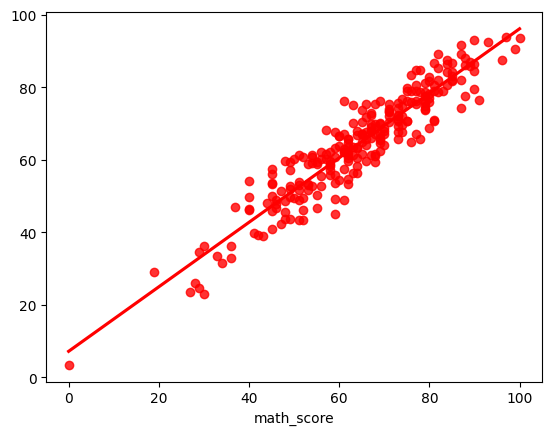

In [26]:
sns.regplot(x=y_test,y=y_prediction,ci=None,color ='red')

In [28]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_prediction,'Difference':y_test-y_prediction})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.415556,14.584444
737,53,58.835356,-5.835356
740,80,76.907370,3.092630
660,74,76.760032,-2.760032
411,84,87.454007,-3.454007
...,...,...,...
109,70,64.035129,5.964871
430,64,63.158496,0.841504
77,80,82.733853,-2.733853
84,42,39.387374,2.612626
